# 01. EDA — 원본 데이터 탐색

`docs/modeling.md`(팀원 문서)의 발견을 "끝난 결론"이 아니라 "검증해볼 가설"로 재현한다.

In [1]:
import sys
sys.path.insert(0, '.')
import paths
import io, re, zipfile
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 50)
print('RAW_DIR:', paths.RAW_DIR)


RAW_DIR: /Volumes/SSD/hwaseong-commercial/hwaseong-commercial-dataset


## 1-1. 소진공 상가(상권)정보

21개 분기 zip 로드 -> 화성시(시군구코드 41590) 필터 -> 분기별 점포수 추이 -> 2022Q4->2023Q1 이탈 규모 재현 -> 재등장률 재현

**함정**: 2020Q4~2022Q4(9개 분기)는 zip 안에 폴더+zip이 한 겹 더 있고, 2023Q1부터는 시도별 CSV가 zip에 바로 있음. macOS 리소스포크(`._*.zip`)는 걸러낸다.

In [2]:
USECOLS = [
    "상가업소번호", "상호명", "시군구코드", "시군구명", "행정동코드", "행정동명",
    "상권업종대분류명", "상권업종중분류명", "상권업종소분류명", "지번주소", "경도", "위도",
]

# 정규 분기말(0930) 파일이 없는 대신 발간된 비정규 날짜 -> 실제 기준분기 직접 매핑
# (20250930.zip이 없고 20251031.zip로 발간됨 -> 2025Q3)
QUARTER_OVERRIDE = {"20251031": "2025Q3"}


def date8_to_quarter(date8: str) -> str:
    if date8 in QUARTER_OVERRIDE:
        return QUARTER_OVERRIDE[date8]
    y, m = int(date8[:4]), int(date8[4:6])
    q = (m - 1) // 3 + 1
    return f"{y}Q{q}"


def read_gyeonggi_csv(zf: zipfile.ZipFile, name: str) -> pd.DataFrame:
    return pd.read_csv(
        io.BytesIO(zf.read(name)), encoding="utf-8",
        usecols=lambda c: c in USECOLS,
        dtype={"상가업소번호": str, "시군구코드": str, "행정동코드": str},
    )


def load_snapshot(zip_path) -> pd.DataFrame:
    """zip 하나(=분기 하나)에서 경기도 CSV만 꺼내 화성시로 필터링."""
    date8 = re.search(r"(\d{8})", zip_path.stem).group(1)
    quarter = date8_to_quarter(date8)
    with zipfile.ZipFile(zip_path, metadata_encoding="cp949") as z:
        names = z.namelist()
        gg_direct = [n for n in names if "경기" in n and n.endswith(".csv")]
        if gg_direct:
            df = read_gyeonggi_csv(z, gg_direct[0])
        else:
            inner_name = next(n for n in names if n.endswith(".zip"))
            with zipfile.ZipFile(io.BytesIO(z.read(inner_name)), metadata_encoding="cp949") as iz:
                gg_inner = next(n for n in iz.namelist() if "경기" in n and n.endswith(".csv"))
                df = read_gyeonggi_csv(iz, gg_inner)
    df = df[df["시군구코드"] == "41590"].copy()
    df["기준분기"] = quarter
    return df


zip_files = sorted(p for p in paths.SBIZ_DIR.glob("*.zip") if not p.name.startswith("._"))
print("zip 파일 수:", len(zip_files))

sbiz = pd.concat([load_snapshot(p) for p in zip_files], ignore_index=True)
print("전체 shape:", sbiz.shape)
sbiz.head()


zip 파일 수: 21
전체 shape: (817741, 13)


,상가업소번호,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시군구코드,시군구명,행정동코드,행정동명,지번주소,경도,위도,기준분기
0,MA010120220809774253,피자스쿨동탄북,음식,기타 간이,피자,41590,화성시,41590585,동탄1동,경기도 화성시 반송동 83,127.072008,37.208206,2020Q4
1,MA010120220806307591,수황실,수리·개인,욕탕·신체관리,마사지/안마,41590,화성시,41590253,봉담읍,경기도 화성시 봉담읍 와우리 31-1,126.974550,37.213956,2020Q4
2,MA010120220802918072,감탄떡볶이,음식,기타 간이,김밥/만두/분식,41590,화성시,41590590,동탄5동,경기도 화성시 영천동 603-1,127.104406,37.208092,2020Q4
3,MA010120220700005275,업소명없음,소매,애완동물·용품 소매,애완동물/애완용품 소매업,41590,화성시,41590400,양감면,경기도 화성시 양감면 용소리 825-2,126.978733,37.081519,2020Q4
4,MA010120220700005925,개똥이네,소매,오락용품 소매,서점,41590,화성시,41590586,동탄2동,경기도 화성시 반송동 129-1,127.077831,37.196507,2020Q4


<Axes: title={'center': '화성시 분기별 상가 점포수 (소진공 원본)'}, xlabel='기준분기'>

/Users/gimgyumin/Desktop/Developer/화성시-AI공모전/hwaseong-commercial-ai/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/gimgyumin/Desktop/Developer/화성시-AI공모전/hwaseong-commercial-ai/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/gimgyumin/Desktop/Developer/화성시-AI공모전/hwaseong-commercial-ai/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/gimgyumin/Desktop/Developer/화성시-AI공모전/hwaseong-commercial-ai/.venv/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/gimgyumin/Desktop/Developer/화성시-

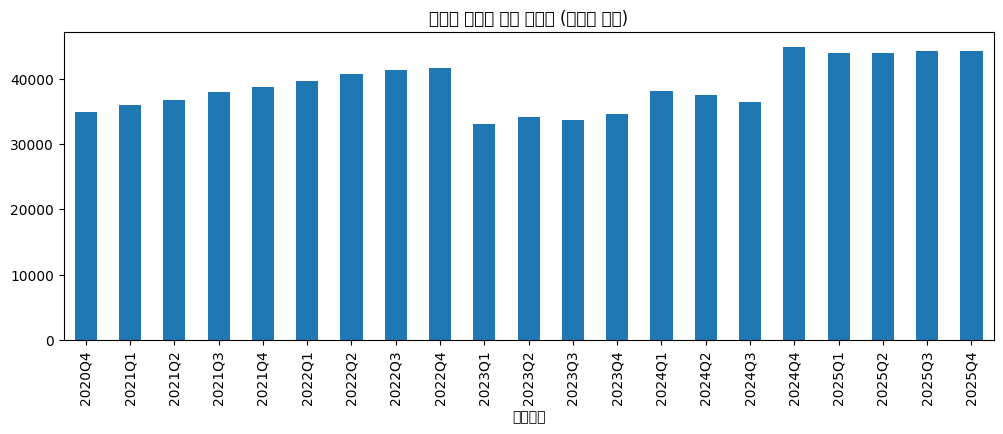

In [3]:
quarters_sorted = sorted(sbiz["기준분기"].unique(), key=lambda q: (int(q[:4]), int(q[5])))
q_idx = {q: i for i, q in enumerate(quarters_sorted)}
sbiz["idx"] = sbiz["기준분기"].map(q_idx)

# 분기별 점포수 추이
counts = sbiz.groupby("기준분기")["상가업소번호"].nunique().reindex(quarters_sorted)
counts.plot(kind="bar", figsize=(12, 4), title="화성시 분기별 상가 점포수 (소진공 원본)")


In [4]:
# 분기별 이탈 규모: 그 분기에 있다가 '다음 분기'엔 없는 점포 수
sets_by_idx = {i: set(g["상가업소번호"]) for i, g in sbiz.groupby("idx")}

departures = {}
for i in range(len(quarters_sorted) - 1):
    departures[quarters_sorted[i]] = len(sets_by_idx[i] - sets_by_idx[i + 1])

dep_series = pd.Series(departures)
print(dep_series)
print("\n2022Q4 이탈 수:", dep_series["2022Q4"])
print("다른 분기 평균 이탈:", dep_series.drop("2022Q4").mean())


2020Q4      842
2021Q1     1340
2021Q2      986
2021Q3     1248
2021Q4      917
2022Q1     1233
2022Q2     1358
2022Q3     1655
2022Q4    11223
2023Q1     2269
2023Q2     1308
2023Q3     1426
2023Q4     1398
2024Q1     1502
2024Q2     1261
2024Q3     4564
2024Q4     3305
2025Q1     2054
2025Q2     3776
2025Q3     1470
dtype: int64

2022Q4 이탈 수: 11223
다른 분기 평균 이탈: 1784.842105263158


In [5]:
# 재등장률: 2022Q4->2023Q1 이탈 점포 중, 이후(2023Q2~) 분기에 다시 나타나는 비율
i22q4 = q_idx["2022Q4"]
departed = sets_by_idx[i22q4] - sets_by_idx[i22q4 + 1]
later_union = set().union(*[sets_by_idx[i] for i in range(i22q4 + 2, len(quarters_sorted))])
reappeared = departed & later_union

print("2022Q4->2023Q1 이탈 점포 수:", len(departed))
print("이후(2023Q2~) 재등장 수:", len(reappeared))
print(f"재등장률: {len(reappeared) / len(departed):.1%}")


2022Q4->2023Q1 이탈 점포 수: 11223
이후(2023Q2~) 재등장 수: 8091
재등장률: 72.1%


## 1-2. 인허가데이터 13종

파일별 컬럼 스키마 비교, 영업상태 분포, 인허가일자 결측률.

**함정**: `학원교습소정보.csv`는 인코딩(utf-8)과 스키마(지번주소·인허가일자 없음, 개설일자/등록일자만 있음)가 나머지 12종(cp949, 지번주소+인허가일자 공통 보유)과 다르다.

In [6]:
permit_files = sorted(p for p in paths.PERMIT_DIR.glob("*.csv") if not p.name.startswith("._"))
print(len(permit_files), "개 파일")

rows = []
for p in permit_files:
    df = None
    for enc in ["cp949", "utf-8"]:
        try:
            df = pd.read_csv(p, encoding=enc, low_memory=False)
            break
        except UnicodeDecodeError:
            continue
    status_col = next((c for c in df.columns if "영업상태명" in c), None)
    date_col = next((c for c in df.columns if "인허가일자" in c), None)
    addr_col = "지번주소" if "지번주소" in df.columns else None
    rows.append({
        "파일": p.name, "행수": len(df), "인코딩": enc, "지번주소": addr_col is not None,
        "인허가일자결측률": df[date_col].isna().mean() if date_col else None,
        "영업중_비율": (df[status_col] == "영업/정상").mean() if status_col else None,
    })

pd.DataFrame(rows)


13 개 파일


,파일,행수,인코딩,지번주소,인허가일자결측률,영업중_비율
0,건강_약국_경기화성시.csv,858,cp949,True,0.0,0.399767
1,문화_노래연습장업_경기화성시.csv,851,cp949,True,0.0,0.467685
2,문화_인터넷컴퓨터게임시설제공업_경기ᄒ...,1036,cp949,True,0.0,0.416988
3,생활_대규모점포_경기화성시.csv,22,cp949,True,0.0,0.681818
4,생활_미용업_경기화성시.csv,5606,cp949,True,0.0,0.556011
5,생활_세탁업_경기화성시.csv,548,cp949,True,0.0,0.366788
6,생활_이용업_경기화성시.csv,351,cp949,True,0.0,0.381766
7,생활_체력단련장업_경기화성시.csv,441,cp949,True,0.0,0.777778
8,식품_일반음식점_경기화성시.csv,27070,cp949,True,0.0,0.380236
9,식품_제과점영업_경기화성시.csv,851,cp949,True,0.0,0.334900


## 1-3. 카드매출

`STD_YM` 월별 행 수 -> 2024-02~12 결측 재확인, `MDCLASS_INDUTYPE_CD` 분포, `TO`(총계) 코드 비중

In [7]:
card = pd.read_csv(paths.CARD_SALES_CSV, encoding="utf-8")
print("shape:", card.shape)

months = sorted(card["STD_YM"].unique())
all_months = pd.period_range(str(months[0]), str(months[-1]), freq="M").strftime("%Y%m").astype(int).tolist()
missing_months = sorted(set(all_months) - set(months))
print("데이터 범위:", months[0], "~", months[-1], f"({len(months)}개월 존재)")
print("빠진 월:", missing_months)


shape: (89386, 4)
데이터 범위: 201801 ~ 202506 (79개월 존재)
빠진 월: [202402, 202403, 202404, 202405, 202406, 202407, 202408, 202409, 202410, 202411, 202412]


In [8]:
code_counts = card["MDCLASS_INDUTYPE_CD"].value_counts()
print("코드 고유값 수:", card["MDCLASS_INDUTYPE_CD"].nunique())
print("TO(총계) 코드 매출 비중:", card.loc[card['MDCLASS_INDUTYPE_CD'] == 'TO', 'SALES_AMT'].sum() / card['SALES_AMT'].sum())
code_counts.head(15)


코드 고유값 수: 125
TO(총계) 코드 매출 비중: 0.500000000816293


MDCLASS_INDUTYPE_CD
TO    2180
L0    1461
K0    1461
X0    1461
L1    1461
N0    1461
E1    1461
B3    1455
B2    1445
D2    1444
J0    1442
H1    1423
B0    1417
C2    1390
O0    1379
Name: count, dtype: int64

## 1-4. 유동인구 — 깨진 버전 vs 정상 버전

깨진 파일(`유동인구_화성시_행정동_시간대별.csv`)이 정말 행정동 구분이 안 되는지 확인 + 정상 버전(`floating_pop_hwaseong.csv`, 신규 확보)의 실제 분포 확인

In [9]:
broken = pd.read_csv(paths.FLOATING_POP_BROKEN_CSV, encoding="utf-8")
print("broken shape:", broken.shape)

sample = broken[(broken["기준년월"] == broken["기준년월"].iloc[0]) & (broken["시간대코드"] == broken["시간대코드"].iloc[0])]
print("동일 (기준년월, 시간대) 조합의 행정동 수:", sample["행정동명"].nunique())
print("그중 유동인구수 고유값 수:", sample["유동인구수"].nunique(), "(1이면 전부 동일 = 깨짐 확인)")


broken shape: (23760, 11)
동일 (기준년월, 시간대) 조합의 행정동 수: 24
그중 유동인구수 고유값 수: 1 (1이면 전부 동일 = 깨짐 확인)


In [10]:
ok = pd.read_csv(paths.FLOATING_POP_CSV, encoding="utf-8")
print("ok shape:", ok.shape)

one_month = ok[ok["STD_YM"] == ok["STD_YM"].max()]
print("최신월 행정동 수:", one_month["ADMDONG_CD"].nunique())
print("그중 유동인구값 고유값 수:", one_month["DYNMC_POPLTN_CNT"].nunique(), "(정상적으로 다양함)")
print("데이터 범위:", ok["STD_YM"].min(), "~", ok["STD_YM"].max(), f"({ok['STD_YM'].nunique()}개월)")


ok shape: (19984, 11)
최신월 행정동 수: 29
그중 유동인구값 고유값 수: 232 (정상적으로 다양함)
데이터 범위: 201801 ~ 202506 (89개월)


## 1-5. KOSIS 세대·인구 / 사업체·종사자수 (신규 확보 데이터)

**함정**: KOSIS 원본은 4행 다중헤더(연도/측정항목/측정단위/성별-구분) 구조라 `header=None`으로 읽어 확인해야 함.

In [11]:
kosis_pop_raw = pd.read_csv(paths.KOSIS_HOUSEHOLD_POP_CSV, encoding="cp949", header=None)
print("세대·인구 파일 shape:", kosis_pop_raw.shape)
for i in range(4):
    print(i, kosis_pop_raw.iloc[i, :6].tolist())

years = sorted(set(kosis_pop_raw.iloc[0, 1:]))
dongs = kosis_pop_raw.iloc[4:, 0].tolist()
print("\n연도 범위:", years)
print("행정동 수(합계 제외):", len(dongs) - 1, "->", dongs)


세대·인구 파일 shape: (34, 76)
0 ['읍면동별(1)', '2019', '2019', '2019', '2019', '2019']
1 ['읍면동별(1)', '세대 수 (세대)', '등록인구 (명)', '등록인구 (명)', '등록인구 (명)', '등록인구 (명)']
2 ['읍면동별(1)', '소계', '합계', '합계', '합계', '한국인']
3 ['읍면동별(1)', '소계', '소계', '남', '여', '소계']

연도 범위: ['2019', '2020', '2021', '2022', '2023']
행정동 수(합계 제외): 29 -> ['합계', '봉담읍', '우정읍', '향남읍', '남양읍', '매송면', '비봉면', '마도면', '송산면', '서신면', '팔탄면', '장안면', '양감면', '정남면', '새솔동', '진안동', '병점1동', '병점2동', '반월동', '기배동', '화산동', '동탄1동', '동탄2동', '동탄3동', '동탄4동', '동탄5동', '동탄6동', '동탄7동', '동탄8동', '동탄9동']


In [12]:
kosis_biz_raw = pd.read_csv(paths.KOSIS_BUSINESS_CSV, encoding="cp949", header=None)
print("사업체·종사자수 파일 shape:", kosis_biz_raw.shape)
for i in range(4):
    print(i, kosis_biz_raw.iloc[i, :6].tolist())


사업체·종사자수 파일 shape: (34, 216)
0 ['읍면동별(1)', '2019', '2019', '2019', '2019', '2019']
1 ['읍면동별(1)', '합계', '합계', '합계', '합계', '합계']
2 ['읍면동별(1)', '사업체수 (개)', '사업체수 (개)', '종사자수 (명)', '종사자수 (명)', '종사자수 (명)']
3 ['읍면동별(1)', '소계', '여성대표자', '계', '남성', '여성']


## 1-6. R-ONE 임대동향·인구동향

지역 구분 컬럼 고유값 확인(팀원 문서: 경기/광주/동탄2신도시/동탄센트럴파크/병점역/화성남양읍/화성봉담읍 7종), 시계열 범위 확인

In [13]:
vacancy_files = [p for p in paths.RENT_VACANCY_DIR.glob("*.csv") if not p.name.startswith("._")]
regions = set()
for p in vacancy_files:
    df = pd.read_csv(p, encoding="cp949")
    col = "지역.1" if "지역.1" in df.columns else ("분류.1" if "분류.1" in df.columns else None)
    if col:
        regions |= set(df[col].dropna().unique())
print(len(vacancy_files), "개 공실률 파일")
print("지역 구분 고유값:", sorted(regions))


11 개 공실률 파일
지역 구분 고유값: ['경기', '광주', '동탄2신도시', '동탄센트럴파크', '병점역', '분류', '지역', '화성남양읍', '화성봉담읍']


In [14]:
index_files = [p for p in paths.RENT_INDEX_DIR.glob("*.csv") if not p.name.startswith("._")]
print(len(index_files), "개 임대가격지수 파일:", [p.name for p in index_files])


3 개 임대가격지수 파일: ['임대동향 지역별 임대가격지수(시계열)_소규모 상가 (1).csv', '임대동향 지역별 임대가격지수(시계열)_중대형 상가 (1).csv', '임대동향 지역별 임대가격지수(시계열)_집합 상가.csv']


## 1-7. EDA 인사이트 정리

### 재현 확인 완료
- **2023Q1 라벨 결함**: 2022Q4(41,660개)->2023Q1(33,108개), 이탈 11,223개(다른 분기 평균 1,785개) — 팀원 수치와 거의 일치
- **재등장률 72.1%** (상가업소번호 기준) — 팀원 문서 수치와 정확히 일치, 이탈 대부분이 실제 폐업이 아님을 재확인
- **유동인구 깨진 파일**: 동일 (기준년월,시간대) 조합에서 24개 행정동 값이 전부 동일 — 결함 재확인
- **유동인구 정상 파일**: 29개 행정동에 232개 고유값 — 실제로 쓸 수 있는 데이터 확인. 데이터 범위 2018-01~2025-06(89개월)
- **카드매출 결측**: 2024-02~12(11개월) 정확히 빠짐, `TO`(총계) 코드가 전체 매출의 상당 비중 차지 — 팀원 발견과 일치
- **인허가 12종**: `지번주소`·`인허가일자` 공통 보유, 결측률 0% — 매칭에 바로 쓸 수 있음. `학원교습소정보.csv`는 스키마가 달라(지번주소 없음) 매칭 대상에서 자동 제외됨
- **R-ONE 지역 구분**: 실제로 7종(경기/광주/동탄2신도시/동탄센트럴파크/병점역/화성남양읍/화성봉담읍)뿐 — 화성시 29개 행정동을 다 구분 못 함, 팀원 문서와 일치

### 새로 발견한 사실 (팀원 문서에 없던 것)
- **행정동 수 불일치**: CLAUDE.md는 화성시를 21개 읍면동(읍4+면9+동8)으로 문서화하고 있는데, KOSIS 세대·인구 파일 등 실제 최신 행정구역 기준으로는 **29개 행정동**(동탄9동, 병점1·2동, 화산동, 진안동, 새솔동, 반월동, 기배동 등 8개 추가)이 확인됨. 동탄 신도시 등 행정동 분리가 반영된 것으로 보임 — Phase 2 이후 GeoJSON(`frontend/public/hwaseong_emd.geojson`)·DB 읍면동 목록과 반드시 대조 필요
- 카드매출/유동인구 결측·단절 시점이 라벨 결함(2023Q1) 시점과 겹치지 않아 서로 독립적인 데이터 품질 이슈로 보임 — Phase 2에서 각각 별도로 처리
- **R-ONE 공실률 파일 헤더 잔재**: `지역`/`분류` 컬럼 고유값에 실제 지역명 외에 `"분류"`, `"지역"` 문자열 자체가 값으로 섞여 나옴(다중행 헤더 중 일부가 데이터로 잘못 파싱됨, 특히 `일반 상가` 파일이 `분류`/`분류.1` 컬럼명을 씀) — Phase 2에서 헤더 파싱 시 명시적으로 걸러내야 함
